In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')


try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    try:
        plt.style.use('seaborn-darkgrid')
    except:
        plt.style.use('default')
sns.set_palette("husl")


In [14]:
tfidf_features = pd.read_csv('tfidf_features.csv')
tfidf_features.head()


,tfidf_0,tfidf_1,tfidf_2,tfidf_3,tfidf_4,tfidf_5,tfidf_6,tfidf_7,tfidf_8,tfidf_9,...,tfidf_40,tfidf_41,tfidf_42,tfidf_43,tfidf_44,tfidf_45,tfidf_46,tfidf_47,tfidf_48,tfidf_49
0,0.000000,0.000000,0.000000,0.000000,0.128839,0.181038,0.00000,0.0,0.000000,0.0,...,0.0,0.000000,0.000000,0.0,0.0,0.350243,0.000000,0.000000,0.000000,0.000000
1,0.000000,0.000000,0.000000,0.000000,0.128839,0.181038,0.00000,0.0,0.000000,0.0,...,0.0,0.000000,0.000000,0.0,0.0,0.350243,0.000000,0.000000,0.000000,0.000000
2,0.196077,0.196077,0.241647,0.241647,0.089190,0.000000,0.17967,0.0,0.241647,0.0,...,0.0,0.185857,0.185857,0.0,0.0,0.000000,0.173179,0.241647,0.241647,0.241647
3,0.000000,0.000000,0.000000,0.000000,0.128839,0.181038,0.00000,0.0,0.000000,0.0,...,0.0,0.000000,0.000000,0.0,0.0,0.350243,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.000000,0.128839,0.181038,0.00000,0.0,0.000000,0.0,...,0.0,0.000000,0.000000,0.0,0.0,0.350243,0.000000,0.000000,0.000000,0.000000


In [15]:
# Prepare data for anomaly detection
X = tfidf_features.values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Data shape: {X_scaled.shape}")
print(f"Scaled data statistics:")
print(f"  Mean: {X_scaled.mean():.4f}")
print(f"  Std: {X_scaled.std():.4f}")


Data shape: (1999, 50)
Scaled data statistics:
  Mean: 0.0000
  Std: 1.0000


We'll implement three anomaly detection algorithms and compare them to select the best model:
1. **Isolation Forest** 
2. **One-Class SVM** 
3. **Local Outlier Factor (LOF)** 


In [16]:
# Model 1: Isolation Forest
iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.02,  # Expected proportion of anomalies (2%)
    random_state=42,
    n_jobs=-1
)

iso_forest.fit(X_scaled)
iso_predictions = iso_forest.predict(X_scaled)
iso_scores = iso_forest.score_samples(X_scaled)

# Convert predictions: -1 = anomaly, 1 = normal -> 1 = anomaly, 0 = normal
iso_labels = (iso_predictions == -1).astype(int)

print(f"\nAnomaly predictions:")
print(f"  Normal instances: {(iso_labels == 0).sum()}")
print(f"  Anomaly instances: {(iso_labels == 1).sum()}")
print(f"  Anomaly percentage: {(iso_labels == 1).mean() * 100:.2f}%")
print(f"\nScore statistics:")
print(f"  Min score: {iso_scores.min():.4f}")
print(f"  Max score: {iso_scores.max():.4f}")
print(f"  Mean score: {iso_scores.mean():.4f}")
print(f"  Std score: {iso_scores.std():.4f}")



Anomaly predictions:
  Normal instances: 1969
  Anomaly instances: 30
  Anomaly percentage: 1.50%

Score statistics:
  Min score: -0.5934
  Max score: -0.4479
  Mean score: -0.5021
  Std score: 0.0245


In [17]:
# Model 2: One-Class SVM
oc_svm = OneClassSVM(
    kernel='rbf',
    nu=0.1,  # Upper bound on fraction of outliers (10%)
    gamma='scale'
)

oc_svm_predictions = oc_svm.fit_predict(X_scaled)
oc_svm_scores = oc_svm.decision_function(X_scaled)

# Convert predictions: -1 = anomaly, 1 = normal -> 1 = anomaly, 0 = normal
oc_svm_labels = (oc_svm_predictions == -1).astype(int)

print(f"\nAnomaly predictions:")
print(f"  Normal instances: {(oc_svm_labels == 0).sum()}")
print(f"  Anomaly instances: {(oc_svm_labels == 1).sum()}")
print(f"  Anomaly percentage: {(oc_svm_labels == 1).mean() * 100:.2f}%")
print(f"\nScore statistics:")
print(f"  Min score: {oc_svm_scores.min():.4f}")
print(f"  Max score: {oc_svm_scores.max():.4f}")
print(f"  Mean score: {oc_svm_scores.mean():.4f}")
print(f"  Std score: {oc_svm_scores.std():.4f}")



Anomaly predictions:
  Normal instances: 1342
  Anomaly instances: 657
  Anomaly percentage: 32.87%

Score statistics:
  Min score: -11.2863
  Max score: 0.7802
  Mean score: 0.0016
  Std score: 0.4490


In [18]:
# Model 3: Local Outlier Factor (LOF)
lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.1,  # Expected proportion of anomalies
    novelty=False,
    n_jobs=-1
)

lof_predictions = lof.fit_predict(X_scaled)
lof_scores = -lof.negative_outlier_factor_  # Negative scores, higher = more anomalous

# Convert predictions: -1 = anomaly, 1 = normal -> 1 = anomaly, 0 = normal
lof_labels = (lof_predictions == -1).astype(int)

print(f"\nAnomaly predictions:")
print(f"  Normal instances: {(lof_labels == 0).sum()}")
print(f"  Anomaly instances: {(lof_labels == 1).sum()}")
print(f"  Anomaly percentage: {(lof_labels == 1).mean() * 100:.2f}%")
print(f"\nScore statistics:")
print(f"  Min score: {lof_scores.min():.4f}")
print(f"  Max score: {lof_scores.max():.4f}")
print(f"  Mean score: {lof_scores.mean():.4f}")
print(f"  Std score: {lof_scores.std():.4f}")



Anomaly predictions:
  Normal instances: 1969
  Anomaly instances: 30
  Anomaly percentage: 1.50%

Score statistics:
  Min score: 1.0000
  Max score: 21590732464.4317
  Mean score: 63102803.0322
  Std score: 1148434870.1076


## Model Comparison

We'll compare models based on:
1. **Score Separation**: How well scores separate normal from anomaly predictions




In [19]:
# Comparison Metric 1: Score Separation
# Measure how well the scores separate normal from anomaly predictions

def calculate_separation(anomaly_scores, normal_scores):

    if len(anomaly_scores) == 0 or len(normal_scores) == 0:
        return 0
    mean_anomaly = np.mean(anomaly_scores)
    mean_normal = np.mean(normal_scores)
    std_combined = np.std(np.concatenate([anomaly_scores, normal_scores]))
    
    if std_combined == 0:
        return 0
    separation = abs(mean_anomaly - mean_normal) / std_combined
    return separation

# Calculate separation for each model
iso_separation = calculate_separation(
    iso_scores[iso_labels == 1],
    iso_scores[iso_labels == 0]
)

oc_svm_separation = calculate_separation(
    oc_svm_scores[oc_svm_labels == 1],
    oc_svm_scores[oc_svm_labels == 0]
)

lof_separation = calculate_separation(
    lof_scores[lof_labels == 1],
    lof_scores[lof_labels == 0]
)


print("Score Separation Analysis")
print(f"Isolation Forest separation: {iso_separation:.4f}")
print(f"One-Class SVM separation: {oc_svm_separation:.4f}")
print(f"LOF separation: {lof_separation:.4f}")
print(f"\nHigher separation indicates better distinction between normal and anomalies.")


Score Separation Analysis
Isolation Forest separation: 3.3604
One-Class SVM separation: 0.3073
LOF separation: 3.6613

Higher separation indicates better distinction between normal and anomalies.


In [20]:
# Get predictions from best model
best_model_name = 'Isolation Forest'
best_predictions = iso_labels
best_scores = iso_scores
best_model = iso_forest


print(f"\nUsing {best_model_name} for final predictions:")
print(f"  Normal instances: {(best_predictions == 0).sum()}")
print(f"  Anomaly instances: {(best_predictions == 1).sum()}")
print(f"  Anomaly percentage: {(best_predictions == 1).mean() * 100:.2f}%")



Using Isolation Forest for final predictions:
  Normal instances: 1969
  Anomaly instances: 30
  Anomaly percentage: 1.50%


In [21]:
final_logs=pd.read_csv('logs.csv')
final_logs.sample(5)

,timestamp,log_level,component,message
1660,2011-08-11 07:29:01,INFO,dfs.FSNamesystem,BLOCK* NameSystem.addStoredBlock: blockMap upd...
6,2009-08-11 20:43:24,INFO,dfs.FSNamesystem,BLOCK* NameSystem.addStoredBlock: blockMap upd...
1355,2011-08-11 04:43:04,INFO,dfs.FSNamesystem,BLOCK* NameSystem.delete: blk_-385477787723659...
21,2009-08-11 20:57:39,INFO,dfs.FSNamesystem,BLOCK* NameSystem.addStoredBlock: blockMap upd...
1221,2011-08-11 03:07:45,INFO,dfs.DataNode$DataXceiver,Receiving block blk_7780461223860192433 src: /...


In [22]:
final_logs['anomaly_score']=iso_scores
final_logs['is_anomaly']=iso_labels
final_logs.sample(5)

,timestamp,log_level,component,message,anomaly_score,is_anomaly
879,2010-08-11 21:05:48,INFO,dfs.FSDataset,Deleting block blk_4658551441818960395 file /m...,-0.447916,0
294,2010-08-11 03:03:31,WARN,dfs.DataNode$DataXceiver,10.251.42.191:50010:Got exception while servin...,-0.505922,0
1413,2011-08-11 04:48:22,INFO,dfs.FSDataset,Deleting block blk_8556592730481313831 file /m...,-0.447916,0
188,2010-08-11 01:08:51,INFO,dfs.FSNamesystem,BLOCK* NameSystem.addStoredBlock: blockMap upd...,-0.524612,0
1941,2011-08-11 09:48:32,INFO,dfs.DataNode$PacketResponder,Received block blk_1190791818440776717 of size...,-0.511684,0


In [23]:
final_logs.sort_values("anomaly_score")

,timestamp,log_level,component,message,anomaly_score,is_anomaly
27,2009-08-11 20:59:31,INFO,dfs.DataBlockScanner,Verification succeeded for blk_-49809165198942...,-0.593406,1
1091,2010-08-11 23:01:05,INFO,dfs.DataBlockScanner,Verification succeeded for blk_389433546300834...,-0.593406,1
567,2010-08-11 11:21:55,INFO,dfs.DataBlockScanner,Verification succeeded for blk_774612454978154966,-0.593406,1
644,2010-08-11 12:17:58,INFO,dfs.DataBlockScanner,Verification succeeded for blk_164916281990581...,-0.593406,1
753,2010-08-11 15:02:54,INFO,dfs.DataBlockScanner,Verification succeeded for blk_-78033433742231...,-0.593406,1
...,...,...,...,...,...,...
1159,2011-08-11 02:32:34,INFO,dfs.FSDataset,Deleting block blk_4365203784873840210 file /m...,-0.447916,0
1158,2011-08-11 02:32:30,INFO,dfs.FSDataset,Deleting block blk_-3607708283707030582 file /...,-0.447916,0
1157,2011-08-11 02:32:29,INFO,dfs.FSDataset,Deleting block blk_1483582953997932733 file /m...,-0.447916,0
1154,2011-08-11 02:32:16,INFO,dfs.FSDataset,Deleting block blk_-2923662094689783995 file /...,-0.447916,0


In [24]:
anomalies_df = final_logs[final_logs["is_anomaly"] == 1]
anomalies_df.head()


,timestamp,log_level,component,message,anomaly_score,is_anomaly
9,2009-08-11 20:46:55,INFO,dfs.DataNode$PacketResponder,Received block blk_35875081onder: 40051953248 ...,-0.541640,1
27,2009-08-11 20:59:31,INFO,dfs.DataBlockScanner,Verification succeeded for blk_-49809165198942...,-0.593406,1
68,2009-08-11 21:34:36,INFO,dfs.DataBlockScanner,Verification succeeded for blk_-28277162389727...,-0.593406,1
174,2010-08-11 00:23:37,INFO,dfs.DataBlockScanner,Verification succeeded for blk_-15479543530655...,-0.593406,1
195,2010-08-11 01:12:37,INFO,dfs.DataBlockScanner,Verification succeeded for blk_699619438987858...,-0.593406,1


In [25]:
def assign_priority(row):
    if row["is_anomaly"] == 1 and row["log_level"] == "ERROR":
        return "HIGH"
    elif row["is_anomaly"] == 1:
        return "MEDIUM"
    else:
        return "LOW"

final_logs["alert_priority"] = final_logs.apply(assign_priority, axis=1)
final_logs.head(10)

,timestamp,log_level,component,message,anomaly_score,is_anomaly,alert_priority
0,2009-08-11 20:36:15,INFO,dfs.DataNode$PacketResponder,PacketResponder 1 for block blk_38865049064139...,-0.495517,0,LOW
1,2009-08-11 20:38:07,INFO,dfs.DataNode$PacketResponder,PacketResponder 0 for block blk_-6952295868487...,-0.495517,0,LOW
2,2009-08-11 20:40:05,INFO,dfs.FSNamesystem,BLOCK* NameSystem.addStoredBlock: blockMap upd...,-0.524612,0,LOW
3,2009-08-11 20:40:15,INFO,dfs.DataNode$PacketResponder,PacketResponder 2 for block blk_82291938032499...,-0.495517,0,LOW
4,2009-08-11 20:41:06,INFO,dfs.DataNode$PacketResponder,PacketResponder 2 for block blk_-6670958622368...,-0.495517,0,LOW
5,2009-08-11 20:41:32,INFO,dfs.FSNamesystem,BLOCK* NameSystem.addStoredBlock: blockMap upd...,-0.524612,0,LOW
6,2009-08-11 20:43:24,INFO,dfs.FSNamesystem,BLOCK* NameSystem.addStoredBlock: blockMap upd...,-0.524612,0,LOW
7,2009-08-11 20:44:53,INFO,dfs.FSNamesystem,BLOCK* NameSystem.addStoredBlock: blockMap upd...,-0.524612,0,LOW
8,2009-08-11 20:45:25,INFO,dfs.DataNode$PacketResponder,PacketResponder 2 for block blk_57249283928729...,-0.495517,0,LOW
9,2009-08-11 20:46:55,INFO,dfs.DataNode$PacketResponder,Received block blk_35875081onder: 40051953248 ...,-0.541640,1,MEDIUM


In [26]:
# Ensure timestamp column is datetime-like before using .dt
final_logs["timestamp"] = pd.to_datetime(final_logs["timestamp"], errors="coerce")

# Optionally report and drop invalid timestamps
invalid_count = final_logs["timestamp"].isna().sum()
if invalid_count:
	print(f"Warning: {invalid_count} invalid timestamps were set to NaT and will be dropped.")

final_logs = final_logs.dropna(subset=["timestamp"]).copy()

final_logs["minute"] = final_logs["timestamp"].dt.floor("T")



In [27]:
summary = final_logs.groupby("minute").agg(
    anomaly_rate=("is_anomaly", "mean"),
    anomaly_count=("is_anomaly", "sum"),
    total_logs=("is_anomaly", "count")
).reset_index()

In [28]:
summary.head(10)

,minute,anomaly_rate,anomaly_count,total_logs
0,2009-08-11 20:36:00,0.0,0,1
1,2009-08-11 20:38:00,0.0,0,1
2,2009-08-11 20:40:00,0.0,0,2
3,2009-08-11 20:41:00,0.0,0,2
4,2009-08-11 20:43:00,0.0,0,1
5,2009-08-11 20:44:00,0.0,0,1
6,2009-08-11 20:45:00,0.0,0,1
7,2009-08-11 20:46:00,1.0,1,1
8,2009-08-11 20:48:00,0.0,0,2
9,2009-08-11 20:49:00,0.0,0,2


In [29]:
final_logs

,timestamp,log_level,component,message,anomaly_score,is_anomaly,alert_priority,minute
0,2009-08-11 20:36:15,INFO,dfs.DataNode$PacketResponder,PacketResponder 1 for block blk_38865049064139...,-0.495517,0,LOW,2009-08-11 20:36:00
1,2009-08-11 20:38:07,INFO,dfs.DataNode$PacketResponder,PacketResponder 0 for block blk_-6952295868487...,-0.495517,0,LOW,2009-08-11 20:38:00
2,2009-08-11 20:40:05,INFO,dfs.FSNamesystem,BLOCK* NameSystem.addStoredBlock: blockMap upd...,-0.524612,0,LOW,2009-08-11 20:40:00
3,2009-08-11 20:40:15,INFO,dfs.DataNode$PacketResponder,PacketResponder 2 for block blk_82291938032499...,-0.495517,0,LOW,2009-08-11 20:40:00
4,2009-08-11 20:41:06,INFO,dfs.DataNode$PacketResponder,PacketResponder 2 for block blk_-6670958622368...,-0.495517,0,LOW,2009-08-11 20:41:00
...,...,...,...,...,...,...,...,...
1994,2011-08-11 10:16:21,INFO,dfs.DataNode$DataXceiver,Receiving block blk_4198733391373026104 src: /...,-0.507400,0,LOW,2011-08-11 10:16:00
1995,2011-08-11 10:17:35,INFO,dfs.DataNode$PacketResponder,Received block blk_-5815145248455404269 of siz...,-0.511684,0,LOW,2011-08-11 10:17:00
1996,2011-08-11 10:18:04,INFO,dfs.DataNode$DataXceiver,Receiving block blk_-295306975763175640 src: /...,-0.507400,0,LOW,2011-08-11 10:18:00
1997,2011-08-11 10:19:54,INFO,dfs.DataNode$PacketResponder,PacketResponder 0 for block blk_52257196770490...,-0.495517,0,LOW,2011-08-11 10:19:00


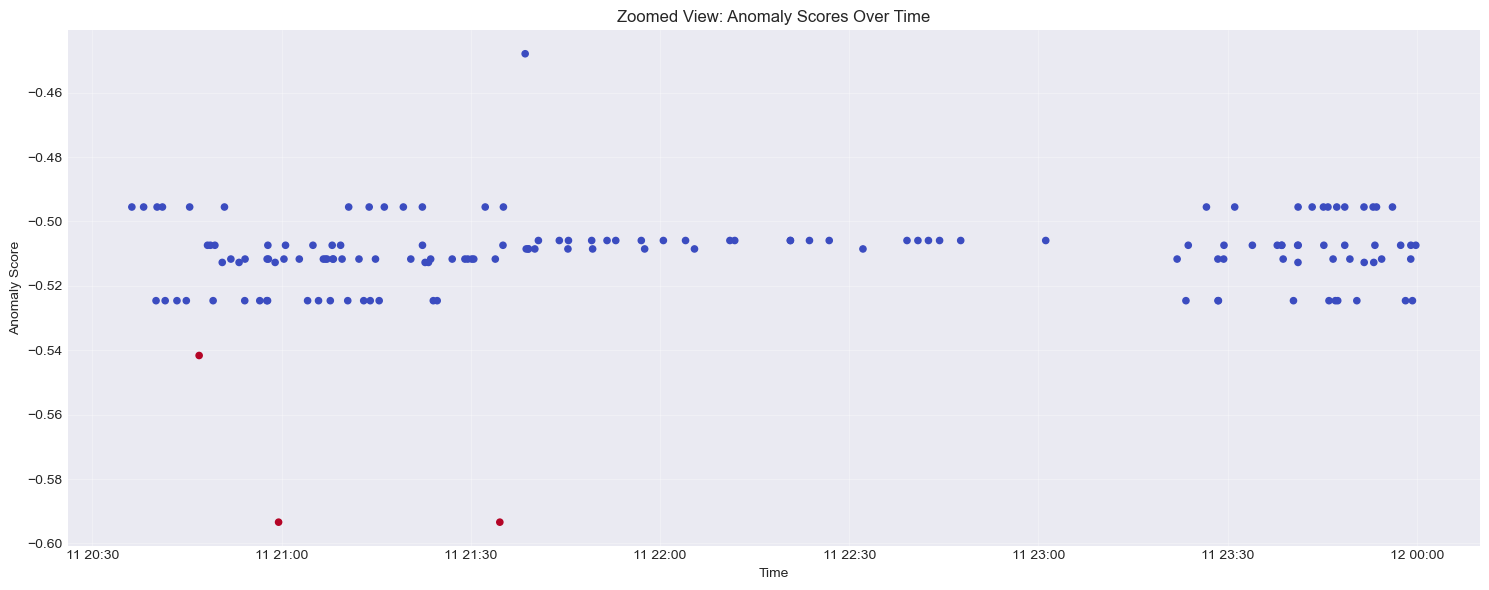

In [30]:
# Choose a window where anomalies exist
start = "2009-08-10"
end   = "2009-10-15"

zoom_df = final_logs[
    (final_logs["timestamp"] >= start) &
    (final_logs["timestamp"] <= end)
]

plt.figure(figsize=(15, 6))

plt.scatter(
    zoom_df["timestamp"],
    zoom_df["anomaly_score"],
    c=zoom_df["is_anomaly"],
    cmap="coolwarm",
    s=20
)

plt.xlabel("Time")
plt.ylabel("Anomaly Score")
plt.title("Zoomed View: Anomaly Scores Over Time")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


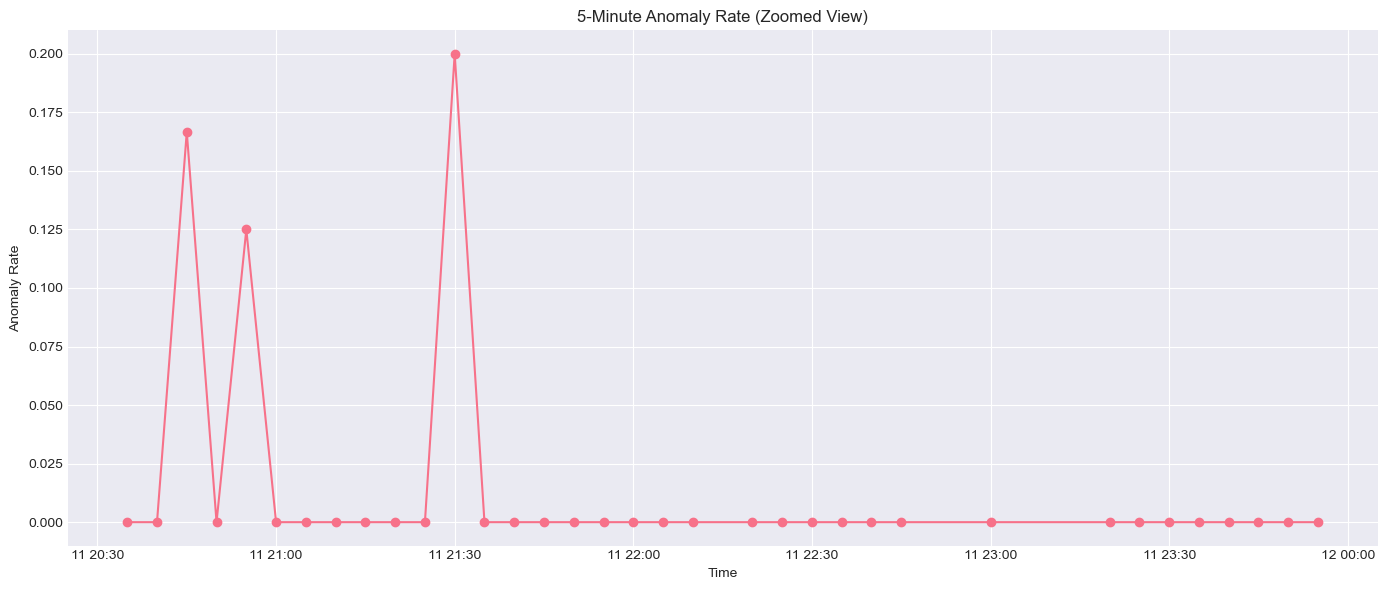

In [31]:
subset = final_logs[
    (final_logs["timestamp"] >= "2009-08-10") &
    (final_logs["timestamp"] <= "2009-10-15")
]

subset["minute"] = subset["timestamp"].dt.floor("5T")

rate_df = subset.groupby("minute")["is_anomaly"].mean().reset_index()

plt.figure(figsize=(14, 6))
plt.plot(rate_df["minute"], rate_df["is_anomaly"], marker="o")
plt.xlabel("Time")
plt.ylabel("Anomaly Rate")
plt.title("5-Minute Anomaly Rate (Zoomed View)")
plt.grid(True)
plt.tight_layout()
plt.show()


In [32]:
#import joblib

#joblib.dump(iso_forest, "isolation_forest_model.pkl")
#joblib.dump(scaler,"scaler.pkl")
